In [39]:
import pandas as pd

df_SL = pd.read_csv('z_score_df_SL_over_US_071626.csv').set_index('peptide')

df_SL_rpk = pd.read_csv('./preprocessing/earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv').set_index('peptide')

df_hbdb = pd.read_csv('z_hbdb_loo_results_071626.csv').set_index('peptide')

df_hbdb_rpk = pd.read_csv('./preprocessing/hbdb_pass_100k_techreps_averaged_071626.csv').set_index('peptide')

peps_metadata = pd.read_csv('lassa_library_sequences_species_standardized_070726.csv').set_index('seq_id')

## keeping peptides that pass z_score > 10 in 10 or more SL individuals

In [40]:
peps_keep = (df_SL > 10).sum(axis=1) #trying z score 
peps_keep = peps_keep[peps_keep > 9]

In [41]:
peps_keep.to_csv('peps_passing_z_score_5_in_10_or_more_SL_072026.csv')

In [42]:
#log transform the rpk matrices same way as for the z score analysis 
import pandas as pd
import numpy as np

df_SL_rpk = df_SL_rpk.apply(pd.to_numeric, errors="coerce").fillna(0.0) #converts every column to a numeric type, if cannot be converted, fills with Nan, but then later NaN gets converted to 0.0

df_SL_log_rpk = np.log10(df_SL_rpk + 1.0)

df_hbdb_rpk = df_hbdb_rpk.apply(pd.to_numeric, errors='coerce').fillna(0.0) #converts every column to a numeric type, if cannot be converted, fills with Nan, but then later NaN gets converted to 0.0

df_hbdb_log_rpk = np.log10(df_hbdb_rpk + 1.0)

In [43]:
print("raw min/max:", df_SL_rpk.min().min(), df_SL_rpk.max().max())
print("log min/max:", df_SL_log_rpk.min().min(), df_SL_log_rpk.max().max())

raw min/max: 0.0 47695.75196486842
log min/max: 0.0 4.678488805627892


In [44]:
#subset to only significant peptides 

peps_metadata = peps_metadata.loc[peps_keep.index]

In [45]:
import numpy as np

df_plot = pd.concat([df_SL, df_hbdb], axis=1)

df_plot_log_rpk = pd.concat([df_SL_log_rpk, df_hbdb_log_rpk], axis=1)

df_plot_log_rpk_sig_peps = df_plot_log_rpk.loc[peps_keep.index]


# Species boxplots using log10(rpk+1) but also z score values. have different agg. functions

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


def species_boxplot(data,  metadata, species:str, agg = "mean", dtype = "z_score"):
    """
    Parameters:
    - data: Pandas DataFrame containing the z score data 
    - x_var: column name 

    """
    species_peps = metadata[metadata['species'] == species]
    df_subset = data.loc[species_peps.index]


    
    #define group Sierra Leone (SL) vs HBDB
    sl_cols = [c for c in df_subset.columns if c.startswith(("C", "S"))]
    hbdb_cols = [c for c in df_subset.columns if c.startswith("HBDB")]

    #with the agg function, each individual (column) gets one value. returns a Series, so a single vector

    if agg == 'mean':
        sl_summary = df_subset[sl_cols].mean(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].mean(axis=0, skipna=True)

    elif agg == 'median':
        sl_summary = df_subset[sl_cols].median(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].median(axis=0, skipna=True)

    elif agg == 'max':
        sl_summary = df_subset[sl_cols].max(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].max(axis=0, skipna=True)

    elif agg == 'sum':
        sl_summary = df_subset[sl_cols].sum(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].sum(axis=0, skipna=True)

    else:
        raise ValueError("agg must be one of: 'mean', 'median' 'max', 'sum'")
 
    plot_df = pd.DataFrame({
        "value": pd.concat([sl_summary, hbdb_summary], axis=0).values,
        "group": ["SL"] * len(sl_summary.index)+ ["HBDB"] * len(hbdb_summary.index),
        "individual": list(sl_summary.index) +list(hbdb_summary.index)
    })

    
    print(df_subset.columns.tolist())
    
    sns.boxplot(data = plot_df, x = "group", y = "value")
    sns.stripplot(data=plot_df, x="group", y="value", color="black", alpha=0.6, jitter=True)
    plt.title(f"{species} peptides {agg} enrichment per individual")
    plt.ylabel(f'{agg} {dtype} score')

    plt.savefig(f'./Figure3_z_10_in_10/{species}_max_{dtype}_enrichment_sl_hbdb_boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()




In [47]:
species = ["Mammarenavirus lassaense", "Plasmodium falciparum", "Orthoflavivirus zikaense", "Orthoflavivirus denguei", "Orthonairovirus haemorrhagiae", "Trypanosoma cruzi"]

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

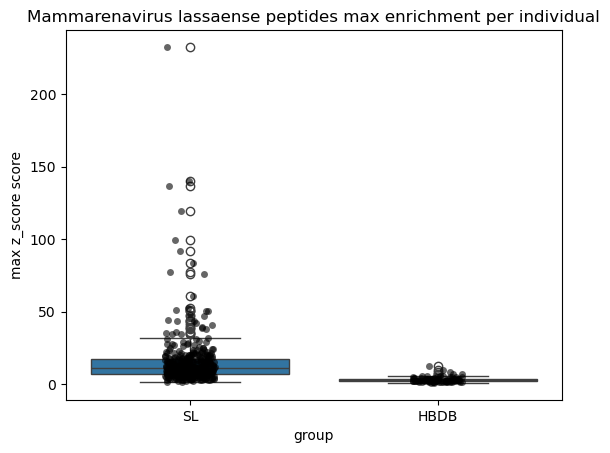

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

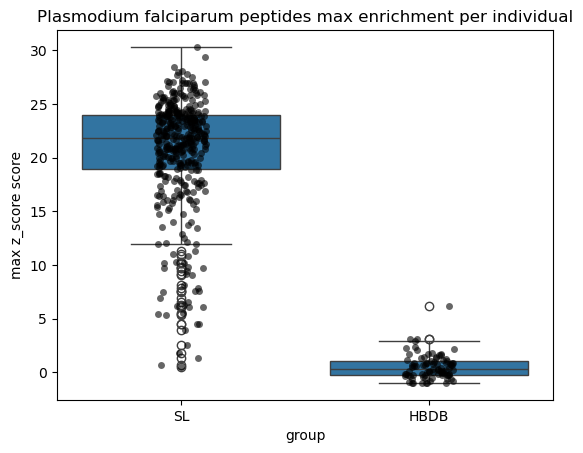

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

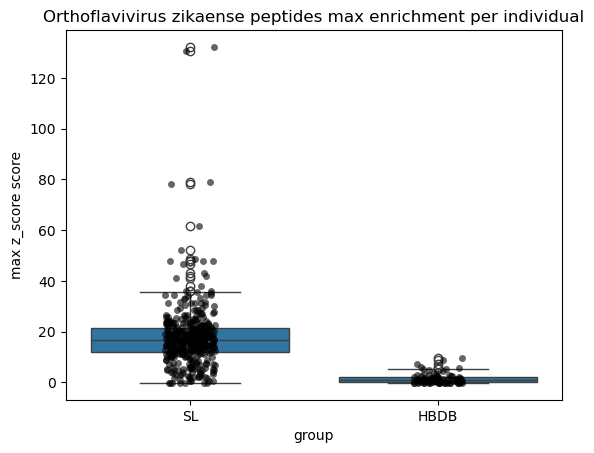

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

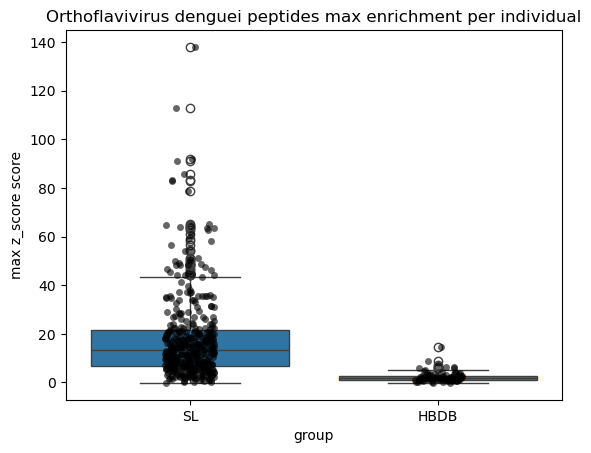

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

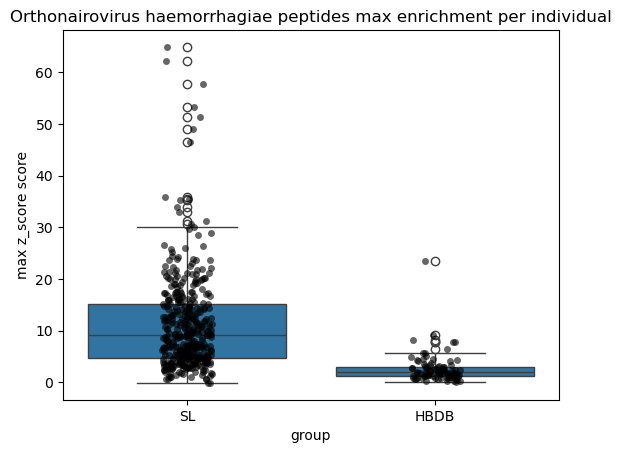

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

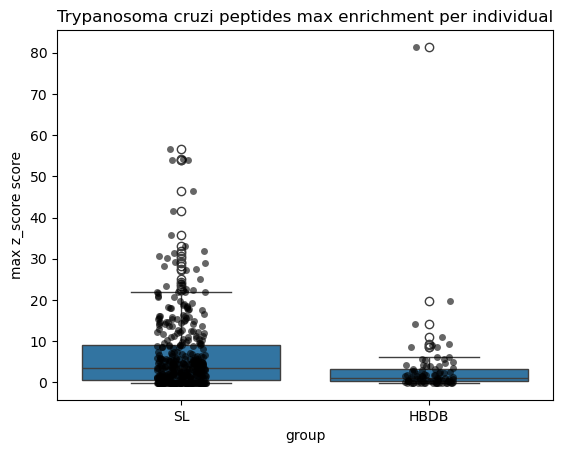

In [49]:
for sp in species:
    species_boxplot(data = df_plot, metadata = peps_metadata, species = sp, agg = 'max')

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

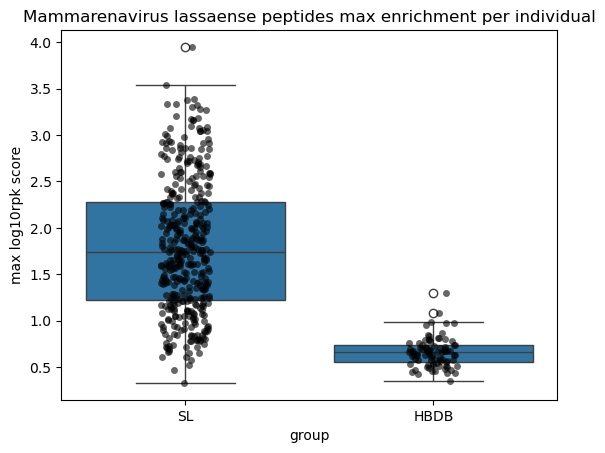

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

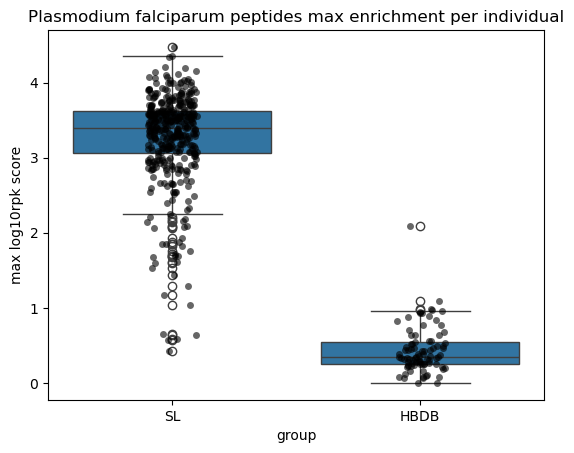

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

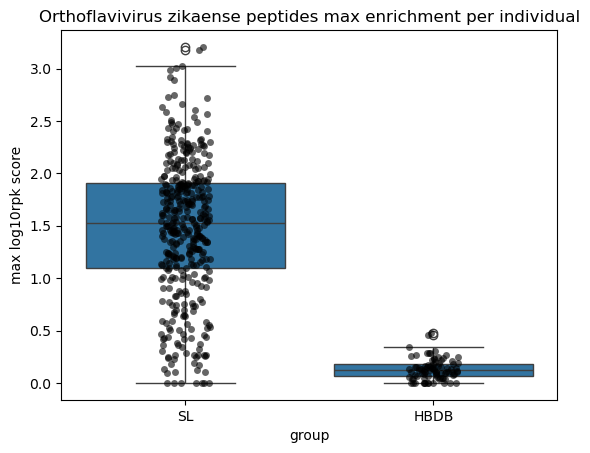

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

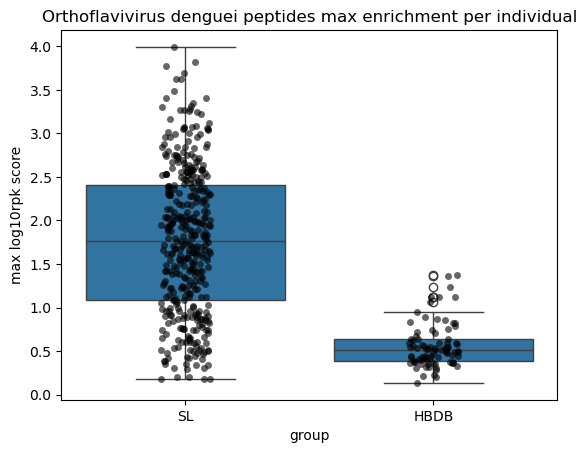

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

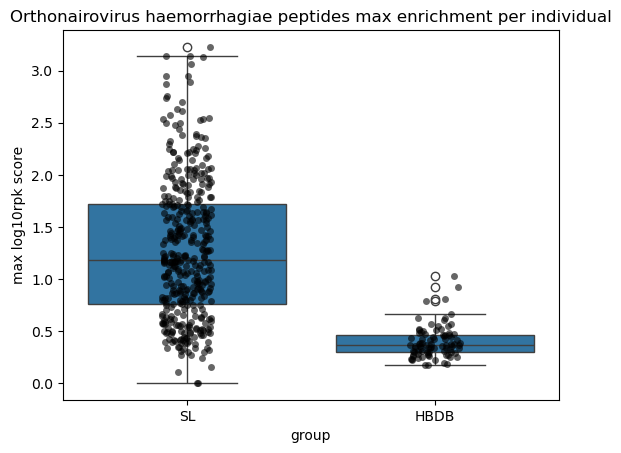

['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113_SA1_B4', 'S-114_SA1_B5', 'S-115_SA1_A5', 'S-125_SA1_C3', 'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-463_SA2_F8', 'S-488_SA1_H2', 'S-502_SA4_I1', 'S-509_SA3_H6', 'C-109-1_5_B3', 'C-114-3_3_B6', 'C-115-3_1_D6', 'C-122-2_3_B8', 'C-137-3_2_A9', 'C-139-2_6_D5', 'C-145-2_2_A6', 'C-145-3_1_E4', 'C-148-3_1_G3', 'C-178-1_1_E1', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4', 'C-462-2_2_D4', 'C-462-3_2_I6', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4', 'C-472-3_2_E9', 'C-475-1_3_G6', 'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-507-3_4_B8', 'C-510-

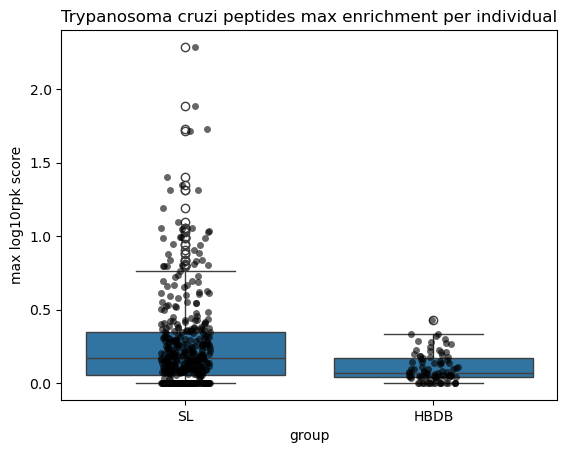

In [50]:
for sp in species:
    species_boxplot(data = df_plot_log_rpk, metadata = peps_metadata, species = sp, agg = 'max', dtype='log10rpk')

# convert log10(RPK+1) to long dataframe with metadata attached, such as sequence, genus, species etc

In [51]:
#Long format for merging with metadata
exposed_rpk_long = (
    df_plot_log_rpk_sig_peps.reset_index()
    .melt(id_vars="peptide", var_name="sample_id", value_name="log10(rpk+1)")
    .merge(
        peps_metadata[[
            "sequence", "family", "genus", "species", "accession", "protein_name"
        ]],
        on="peptide",
        how="left"
    )
).set_index('peptide')

In [52]:
exposed_rpk_long.index.nunique()

545

In [ ]:
#exposed_rpk_long.to_csv('long_log10rpk_df_peps_z_3_in_5_SL_and_USHC_071726.csv')

# Now map phip seq signal to LASV proteins NP and GC panel 3b

## alignment function

In [53]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Align

#-- creates a pairwise sequence aligner
aligner = Align.PairwiseAligner()
aligner.mode = "local" #will find the best matching region between two sequences, not necessarily end-to-end
aligner.match_score = 2 #identical letters get +2
aligner.mismatch_score = -1 #different letteres get -1
aligner.open_gap_score = -5 #starting a gap is penalized heavily
aligner.extend_gap_score = -1 #extending an existing gap is penalized less

def map_peptide(peptide, reference):
    #defines a function that tries to map one peptide onto the reference sequence
    #exact substring match. Pos is the starting index if found, or -1 if not found.
    pos = reference.find(peptide) 
    if pos != -1: #if the peptide is found exactly, then start is recorded using 1-based numbering
        #end is the last residue position of the match. method: exact marks this as a perfect substring match
        #score is set to peptide length as a simple score
        return {
            "pep": peptide,
            "start": pos + 1,               # 1-based
            "end": pos + len(peptide),      # 1-based inclusive
            "method": "exact",
            "score": len(peptide),
        }

    # fallback: local alignment
    #if exact matching fails, do aligner, mode is set to 'local'
    #so alns = aligner.align(reference, peptide) returns an alignment object collection. 
    #alns contains all possible alignments, ranked by score. 
    alns = aligner.align(reference, peptide)
    if len(alns) == 0:
        return {
            "pep": peptide,
            "start": None,
            "end": None,
            "method": "unmapped",
            "score": np.nan,
        }

    aln = alns[0] #finds the best alignment, which is the first one returned
    #when you print this best possible alignment, you get two arrays. the first array are the coordinates
    #on the reference sequence. array([[6, 12]]) for example means reference[6:12] is aligned. 
    #The second array, are the coordinates on the peptide. So array([[0, 6]]) for example means that
    #peptide[0:6] is aligned. The best alignment may contain two matching blocks, indicating that 
    #the best alignment has two matching blocks. One aligned block from e.g. 0-2, another from 3-7.
    
    ref_blocks = aln.aligned[0]   # list of (start, end) blocks on reference
    if len(ref_blocks) == 0:
        return {
            "pep": peptide,
            "start": None,
            "end": None,
            "method": "unmapped",
            "score": np.nan,
        }

    start = ref_blocks[0][0] + 1 #this here is the beginning of the first aligned block, converted to 1-based indexing
    #suppose ref_blocks is array([[6, 13]]), then ref_blocks[0] is [6, 13] which is the first aligned block. 
    #then ref_blocks[0][0] is 6, which is the starting python index. adding one gives 7, because protein residue
    #numbering is conventionally 1-based
    end = ref_blocks[-1][1] #end of the last aligned block
    #for a simple alignment e.g. [[6, 13]] the first block and the last block are the same. 
    #so ref_blocks[-1] is [6, 13] and ref_blocks[-1][1] is 13, which corresponds to residue 13 in 1-based numbering
    #as biopython alignment uses an exclusive end index. 
    #but sometimes an alignment contains gaps, and the best alignment might be [[0, 3], [6, 9]], so start would be
    #0 + 1 = 1, and end would be 9. even though there is a gap, the peptide is considered to span the entire region
    #from the first aligned residue to the last aligned residue. 

    return { #this returns the peptide mapping result from local alignment
        "pep": peptide, #peptide here is the amino acid sequence for the peptide
        "start": start,
        "end": end,
        "method": "local", 
        "score": aln.score,
    }


## lasv glycoprotein refseq

In [54]:

# >NP_950235.1 glycoprotein precursor [Orthonairovirus haemorrhagiae]
lasv_glycoprotein_refseq = """
>NP_694870.1 glycoprotein [Mammarenavirus lassaense]
MGQIVTFFQEVPHVIEEVMNIVLIALSVLAVLKGLYNFATCGLVGLVTFLLLCGRSCTTSLYKGVYELQT
LELNMETLNMTMPLSCTKNNSHHYIMVGNETGLELTLTNTSIINHKFCNLSDAHKKNLYDHALMSIISTF
HLSIPNFNQYEAMSCDFNGGKISVQYNLSHSYAGDAANHCGTVANGVLQTFMRMAWGGSYIALDSGRGNW
DCIMTSYQYLIIQNTTWEDHCQFSRPSPIGYLGLLSQRTRDIYISRRLLGTFTWTLSDSEGKDTPGGYCL
TRWMLIEAELKCFGNTAVAKCNEKHDEEFCDMLRLFDFNKQAIQRLKAEAQMSIQLINKAVNALINDQLI
MKNHLRDIMGIPYCNYSKYWYLNHTTTGRTSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYM
ERQGKTPLGLVDLFVFSTSFYLISIFLHLVKIPTHRHIVGKSCPKPHRLNHMGICSCGLYKQPGVPVKWK
R

"""

#- reference sequence
#this builds one clean amino-acid reference sequence string called ref_seq
lasv_gpc_ref_seq = "".join( #concatenates all remaining sequence lines into one continuous string
    line.strip() #removes whitespace from each kept line
    for line in lasv_glycoprotein_refseq.splitlines() #splits the input text into lines
    if line and not line.startswith(">") #skips empty lines and FASTA header
)

In [55]:
exposed_rpk_long_lassa = exposed_rpk_long[exposed_rpk_long['species'] == 'Mammarenavirus lassaense']
glycoprotein_valid = ['envelope glycoprotein precursor', 'glycoprotein', 'glycoprotein precursor', 'putative polyprotein', 'gpc']
exposed_rpk_long_lasv_gp = exposed_rpk_long_lassa[exposed_rpk_long_lassa['protein_name'].isin(glycoprotein_valid)]


df_S = df_SL.filter(regex='^S-')
df_C = df_SL.filter(regex='^C-')


exposed_rpk_long_lasv_gp['category'] = "US"
exposed_rpk_long_lasv_gp.loc[exposed_rpk_long_lasv_gp['sample_id'].isin(df_S.columns), "category"] = 'S'
exposed_rpk_long_lasv_gp.loc[exposed_rpk_long_lasv_gp['sample_id'].isin(df_C.columns), "category"] = 'C'

/tmp/ipykernel_2849699/3206332981.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exposed_rpk_long_lasv_gp['category'] = "US"


In [56]:
#.apply() means take every value in this Series and run a function on it
mapped = (
    exposed_rpk_long_lasv_gp["sequence"]
    #use pd.Series(..) so pandas expands the dictionary into columns
    .apply(lambda x: pd.Series(map_peptide(x, lasv_gpc_ref_seq)))
    #.apply() automatically returns a DataFrame
)

## merge mapped/alignment values start and end positions of peptides to exposed_rpk_long_lasv_gp, which has the enrichment values stored

In [ ]:
import numpy as np

#merge mapped/alignment values start and end positions
exposed_rpk_long_lasv_gp_w_mapping = pd.merge(exposed_rpk_long_lasv_gp, mapped[['start', 'end', 'method', 'score']], on = 'peptide', how='left')

protein_length = len(lasv_gpc_ref_seq)

profiles = {}

for sample, group in exposed_rpk_long_lasv_gp_w_mapping.groupby('sample_id', sort=False):
    #splits the dataframe into each sample_id and all rows belonging to that sample_id are a group

    profile = np.zeros(protein_length) #initialize every residue as 0

    for start, end, value in group[['start', 'end', 'log10(rpk+1)']].itertuples(index=False, name=None):
        if pd.isna(value):
            continue

        start = int(start)
        end = int(end)

        profile[start:end] = np.maximum(profile[start:end], float(value))

    profiles[sample] = profile

In [ ]:
exposed_rpk_long_lasv_gp_w_mapping.groupby('sample_id')['log10(rpk+1)']

## use profiles to draw the glycoprotein seroreactivity map - now each individuals maximum amino acid log10(rpk+1) value is being taken and the group average drawn

In [ ]:
profiles_df = pd.DataFrame.from_dict(profiles, orient="index") #this interprets keys as row labels. now the #cols = protein length
#profiles_df.columns = range(1, protein_length + 1) #converting to 1-based indexing
profiles_df.index.name='sample_id'
profiles_df.reset_index()

#mapping to group 

sample_category = (
    exposed_rpk_long_lasv_gp[["sample_id", "category"]]
    .drop_duplicates()
)

profiles_df = profiles_df.merge(sample_category, on="sample_id")

group_mean = (
    profiles_df.groupby("category").mean(numeric_only=True)
)

## reshape to long df with columns category, position, and value to use seaborn plotting

df_long = group_mean.reset_index().melt(
    id_vars='category', #identifier variables (keep category column as is
    var_name='position', #new column with old column names
    value_name='value' #new column with numeric values
)

df_long['value_raw'] = 10 ** df_long['value'] - 1

In [ ]:
df_long.sort_values(by='value_raw', ascending=False)

,category,position,value,value_raw
976,S,325,1.174724,13.952836
916,S,305,1.174724,13.952836
913,S,304,1.174724,13.952836
958,S,319,1.174724,13.952836
910,S,303,1.174724,13.952836
...,...,...,...,...
486,C,162,0.000000,0.000000
485,US,161,0.000000,0.000000
484,S,161,0.000000,0.000000
483,C,161,0.000000,0.000000


### draw the seroreactivity onto glycoprotein using the group mean values

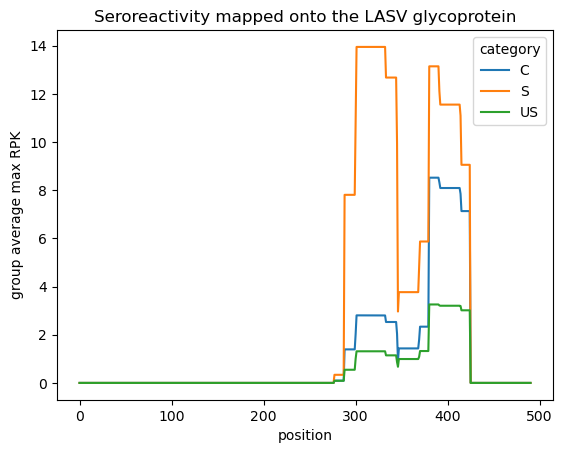

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

x = np.arange(len(lasv_glycoprotein_refseq))

sns.lineplot(data=df_long, x='position', y='value_raw', hue='category')

plt.title('Seroreactivity mapped onto the LASV glycoprotein')
plt.ylabel('group average max RPK')
plt.show()

# same for the LASV Nucleoprotein

In [ ]:
#for the nucleoprotein


# >NP_950235.1 glycoprotein precursor [Orthonairovirus haemorrhagiae]
lasv_nucleoprotein_refseq = """
>NP_694869.1 nucleoprotein [Mammarenavirus lassaense]
MSASKEIKSFLWTQSLRRELSGYCSNIKLQVVKDAQALLHGLDFSEVSNVQRLMRKERRDDNDLKRLRDL
NQAVNNLVELKSTQQKSILRVGTLTSDDLLILAADLEKLKSKVIRTERPLSAGVYMGNLSSQQLDQRRAL
LNMIGMSGGNQGARAGRDGVVRVWDVKNAELLNNQFGTMPSLTLACLTKQGQVDLNDAVQALTDLGLIYT
AKYPNTSDLDRLTQSHPILNMIDTKKSSLNISGYNFSLGAAVKAGACMLDGGNMLETIKVSPQTMDGILK
SILKVKKALGMFISDTPGERNPYENILYKICLSGDGWPYIASRTSITGRAWENTVVDLESDGKPQKADSN
NSSKSLQSAGFTAGLTYSQLMTLKDAMLQLDPNAKTWMDIEGRPEDPVEIALYQPSSGCYIHFFREPTDL
KQFKQDAKYSHGIDVTDLFATQPGLTSAVIDALPRNMVITCQGSDDIRKLLESQGRKDIKLIDIALSKTD
SRKYENAVWDQYKDLCHMHTGVVVEKKKRGGKEEITPHCALMDCIMFDAAVSGGLNTSVLRAVLPRDMVF
RTSTPRVVL

"""

#- reference sequence
#this builds one clean amino-acid reference sequence string called ref_seq
lasv_np_ref_seq = "".join( #concatenates all remaining sequence lines into one continuous string
    line.strip() #removes whitespace from each kept line
    for line in lasv_nucleoprotein_refseq.splitlines() #splits the input text into lines
    if line and not line.startswith(">") #skips empty lines and FASTA header
)

In [ ]:
exposed_rpk_long_lassa = exposed_rpk_long[exposed_rpk_long['species'] == 'Mammarenavirus lassaense']
nucleoprotein_valid = ['nucleoprotein', 'NP', 'nucleocapsid protein']
exposed_rpk_long_lasv_np = exposed_rpk_long_lassa[exposed_rpk_long_lassa['protein_name'].isin(nucleoprotein_valid)]


df_S = df_SL.filter(regex='^S-')
df_C = df_SL.filter(regex='^C-')


exposed_rpk_long_lasv_np['category'] = "US"
exposed_rpk_long_lasv_np.loc[exposed_rpk_long_lasv_np['sample_id'].isin(df_S.columns), "category"] = 'S'
exposed_rpk_long_lasv_np.loc[exposed_rpk_long_lasv_np['sample_id'].isin(df_C.columns), "category"] = 'C'

mean_rpk_per_cat = ( 
    exposed_rpk_long_lasv_np.reset_index()
    .groupby(["peptide", "category"], as_index=False)["log10(rpk+1)"]
    .median()
    .rename(columns={"log10(rpk+1)" : "mean_rpk"})
)

/tmp/ipykernel_2849699/2329402784.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exposed_rpk_long_lasv_np['category'] = "US"


In [ ]:
#.apply() means take every value in this Series and run a function on it
mapped = (
    exposed_rpk_long_lasv_np["sequence"]
    #use pd.Series(..) so pandas expands the dictionary into columns
    .apply(lambda x: pd.Series(map_peptide(x, lasv_np_ref_seq)))
    #.apply() automatically returns a DataFrame
)

In [ ]:
import numpy as np

#merge mapped/alignment values start and end positions
exposed_rpk_long_lasv_np_w_mapping = pd.merge(exposed_rpk_long_lasv_np, mapped[['start', 'end', 'method', 'score']], on = 'peptide', how='left')

protein_length = len(lasv_np_ref_seq)

profiles = {}

for sample, group in exposed_rpk_long_lasv_np_w_mapping.groupby('sample_id', sort=False):
    #splits the dataframe into each sample_id and all rows belonging to that sample_id are a group

    profile = np.zeros(protein_length) #initialize every residue as 0

    for start, end, value in group[['start', 'end', 'log10(rpk+1)']].itertuples(index=False, name=None):
        if pd.isna(value):
            continue

        start = int(start)
        end = int(end)

        profile[start:end] = np.maximum(profile[start:end], float(value))

    profiles[sample] = profile

In [ ]:
profiles_df = pd.DataFrame.from_dict(profiles, orient="index") #this interprets keys as row labels. now the #cols = protein length
#profiles_df.columns = range(1, protein_length + 1) #converting to 1-based indexing
profiles_df.index.name='sample_id'
profiles_df.reset_index()

#mapping to group 

sample_category = (
    exposed_rpk_long_lasv_np[["sample_id", "category"]]
    .drop_duplicates()
)

profiles_df = profiles_df.merge(sample_category, on="sample_id")

group_mean = (
    profiles_df.groupby("category").mean(numeric_only=True)
)

## reshape to long df with columns category, position, and value to use seaborn plotting

df_long = group_mean.reset_index().melt(
    id_vars='category', #identifier variables (keep category column as is
    var_name='position', #new column with old column names
    value_name='value' #new column with numeric values
)

df_long['value_raw'] = (10 ** df_long['value']) - 1

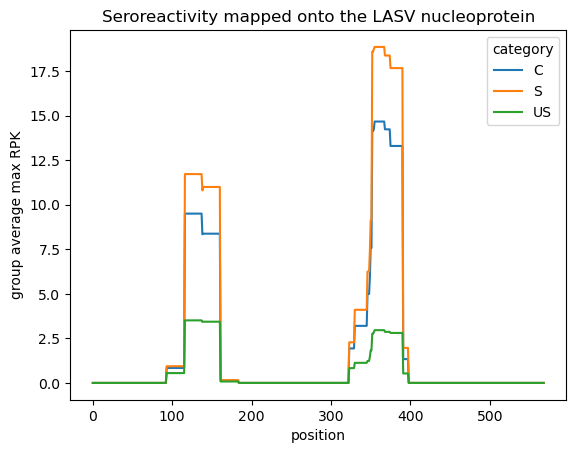

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

x = np.arange(len(lasv_np_ref_seq))

sns.lineplot(data=df_long, x='position', y='value_raw', hue='category')

plt.title('Seroreactivity mapped onto the LASV nucleoprotein')
plt.ylabel('group average max RPK')
plt.show()

# Look at LASV NP and L

# Now look at 'Can we discriminate strain-level serological responses within a person for LASV'

In [ ]:
exposed_rpk_long.index.nunique()

7005

In [ ]:
exposed_rpk_long_lasv = exposed_rpk_long[exposed_rpk_long['species'] == 'Mammarenavirus lassaense']

In [ ]:
pivot_df = exposed_rpk_long_lasv.groupby(['sample_id', 'accession'])['log10(rpk+1)'].max().unstack()

In [ ]:
pivot_df_raw = (10**pivot_df) -1

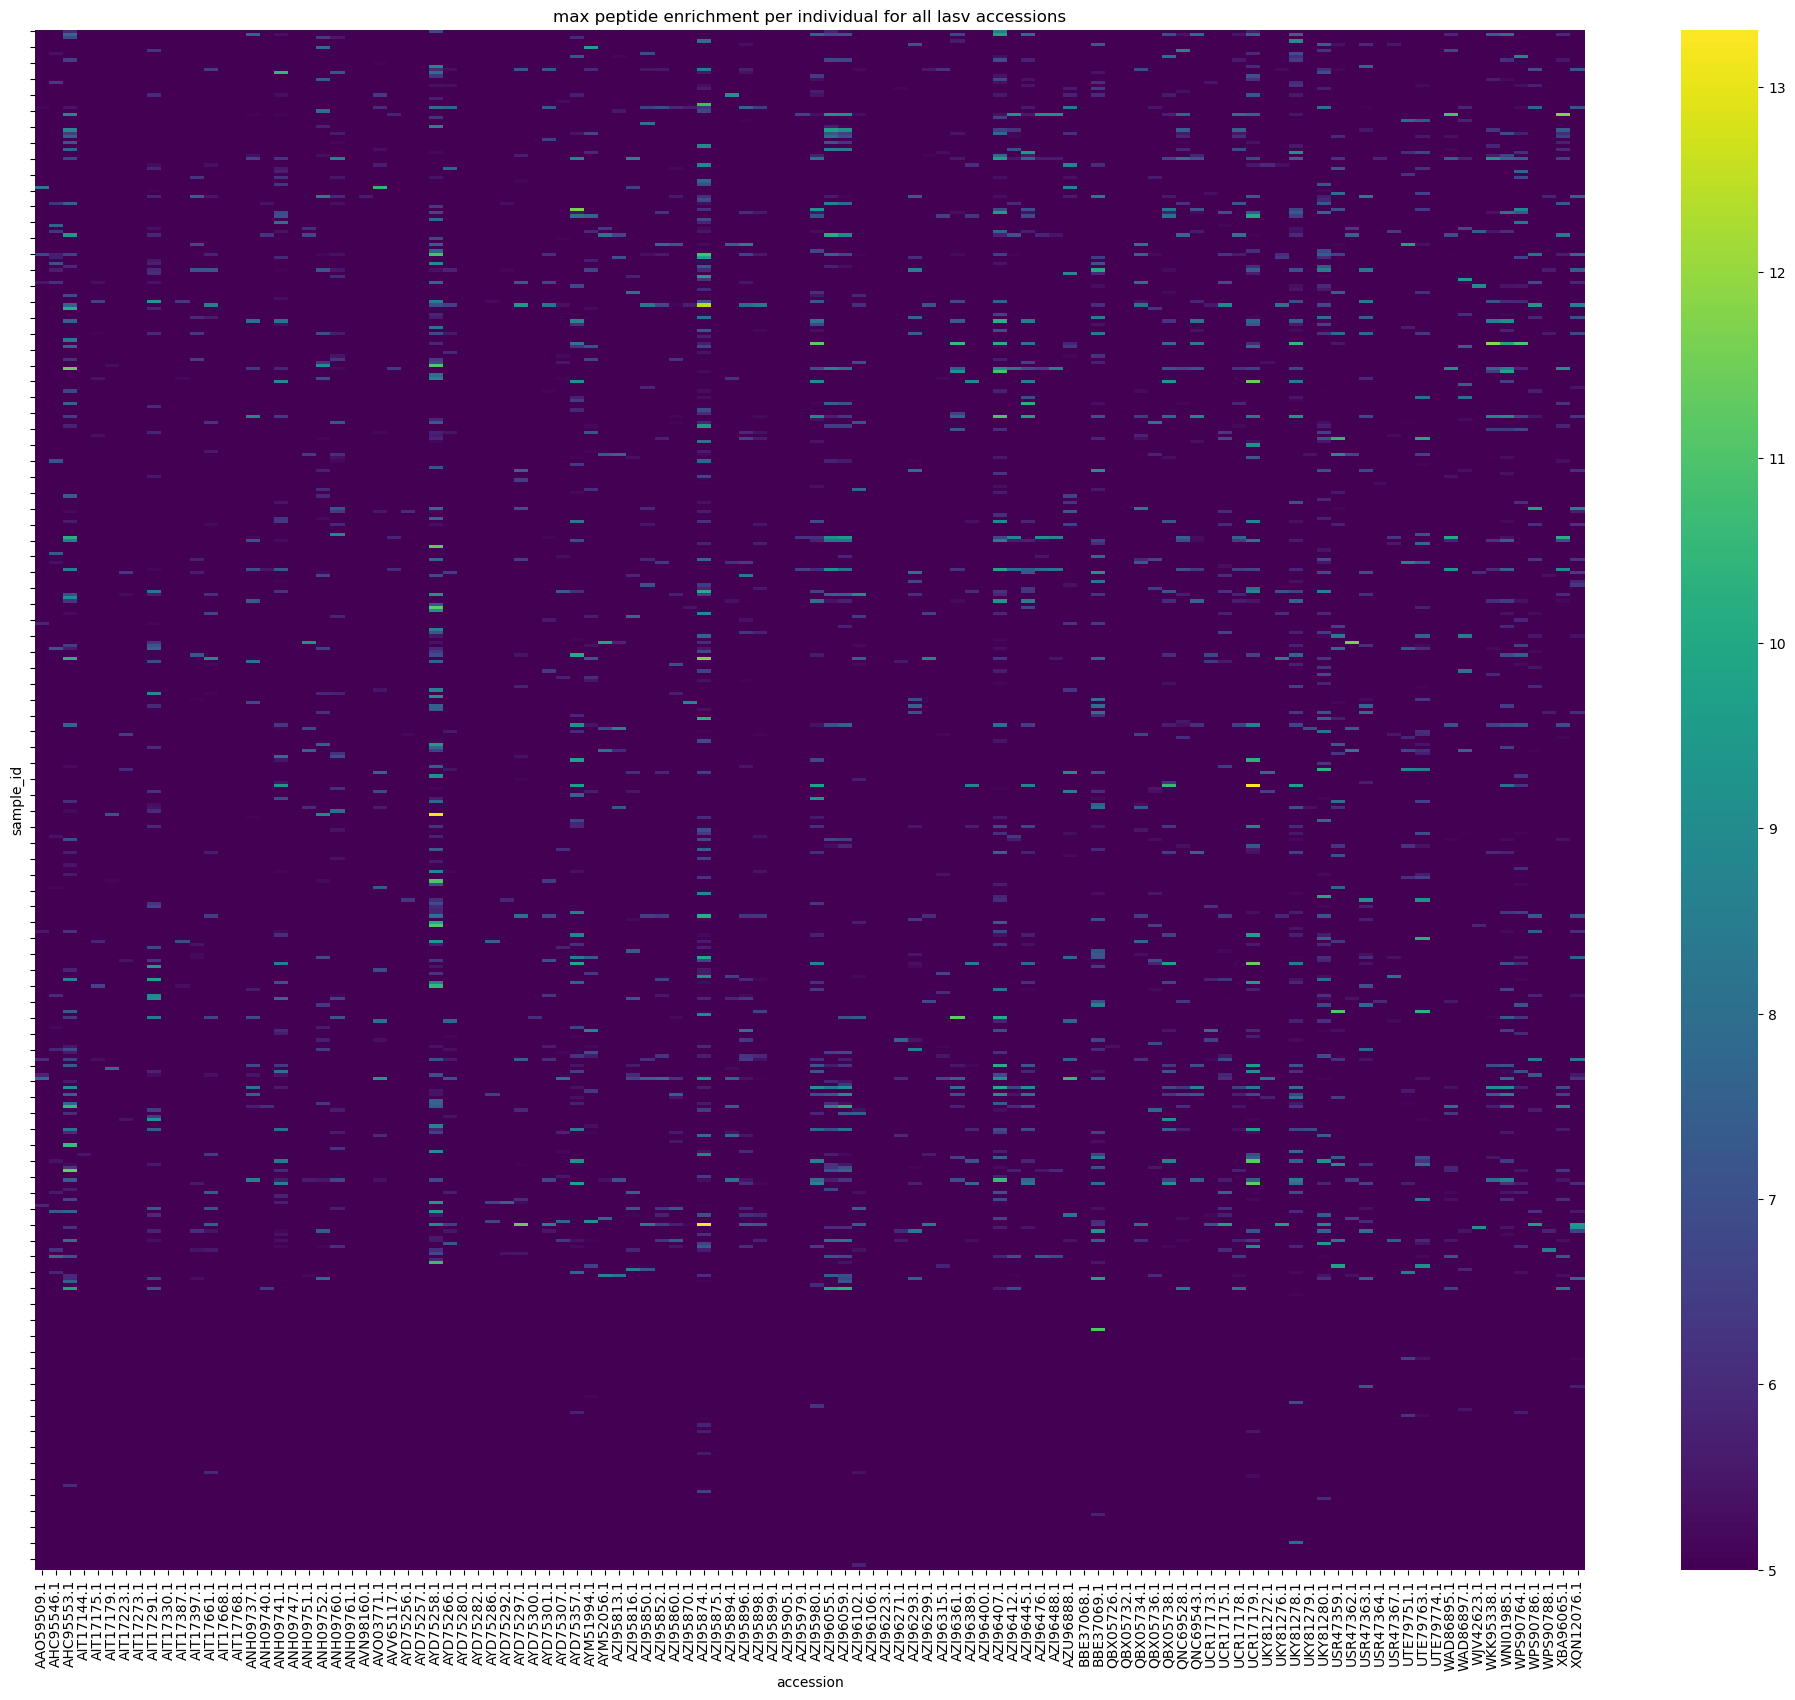

In [ ]:
import seaborn as sns

row_order = list(df_SL.columns) + list(df_hbdb.columns) #order has to be a list

pivot_df = pivot_df.loc[row_order]

plt.figure(figsize=(25, 20))

ax = sns.heatmap(np.log2(pivot_df), cmap='viridis', vmin=5)

ax.tick_params(axis='y', labelleft=False)

plt.title('max peptide enrichment per individual for all lasv accessions')

plt.show()


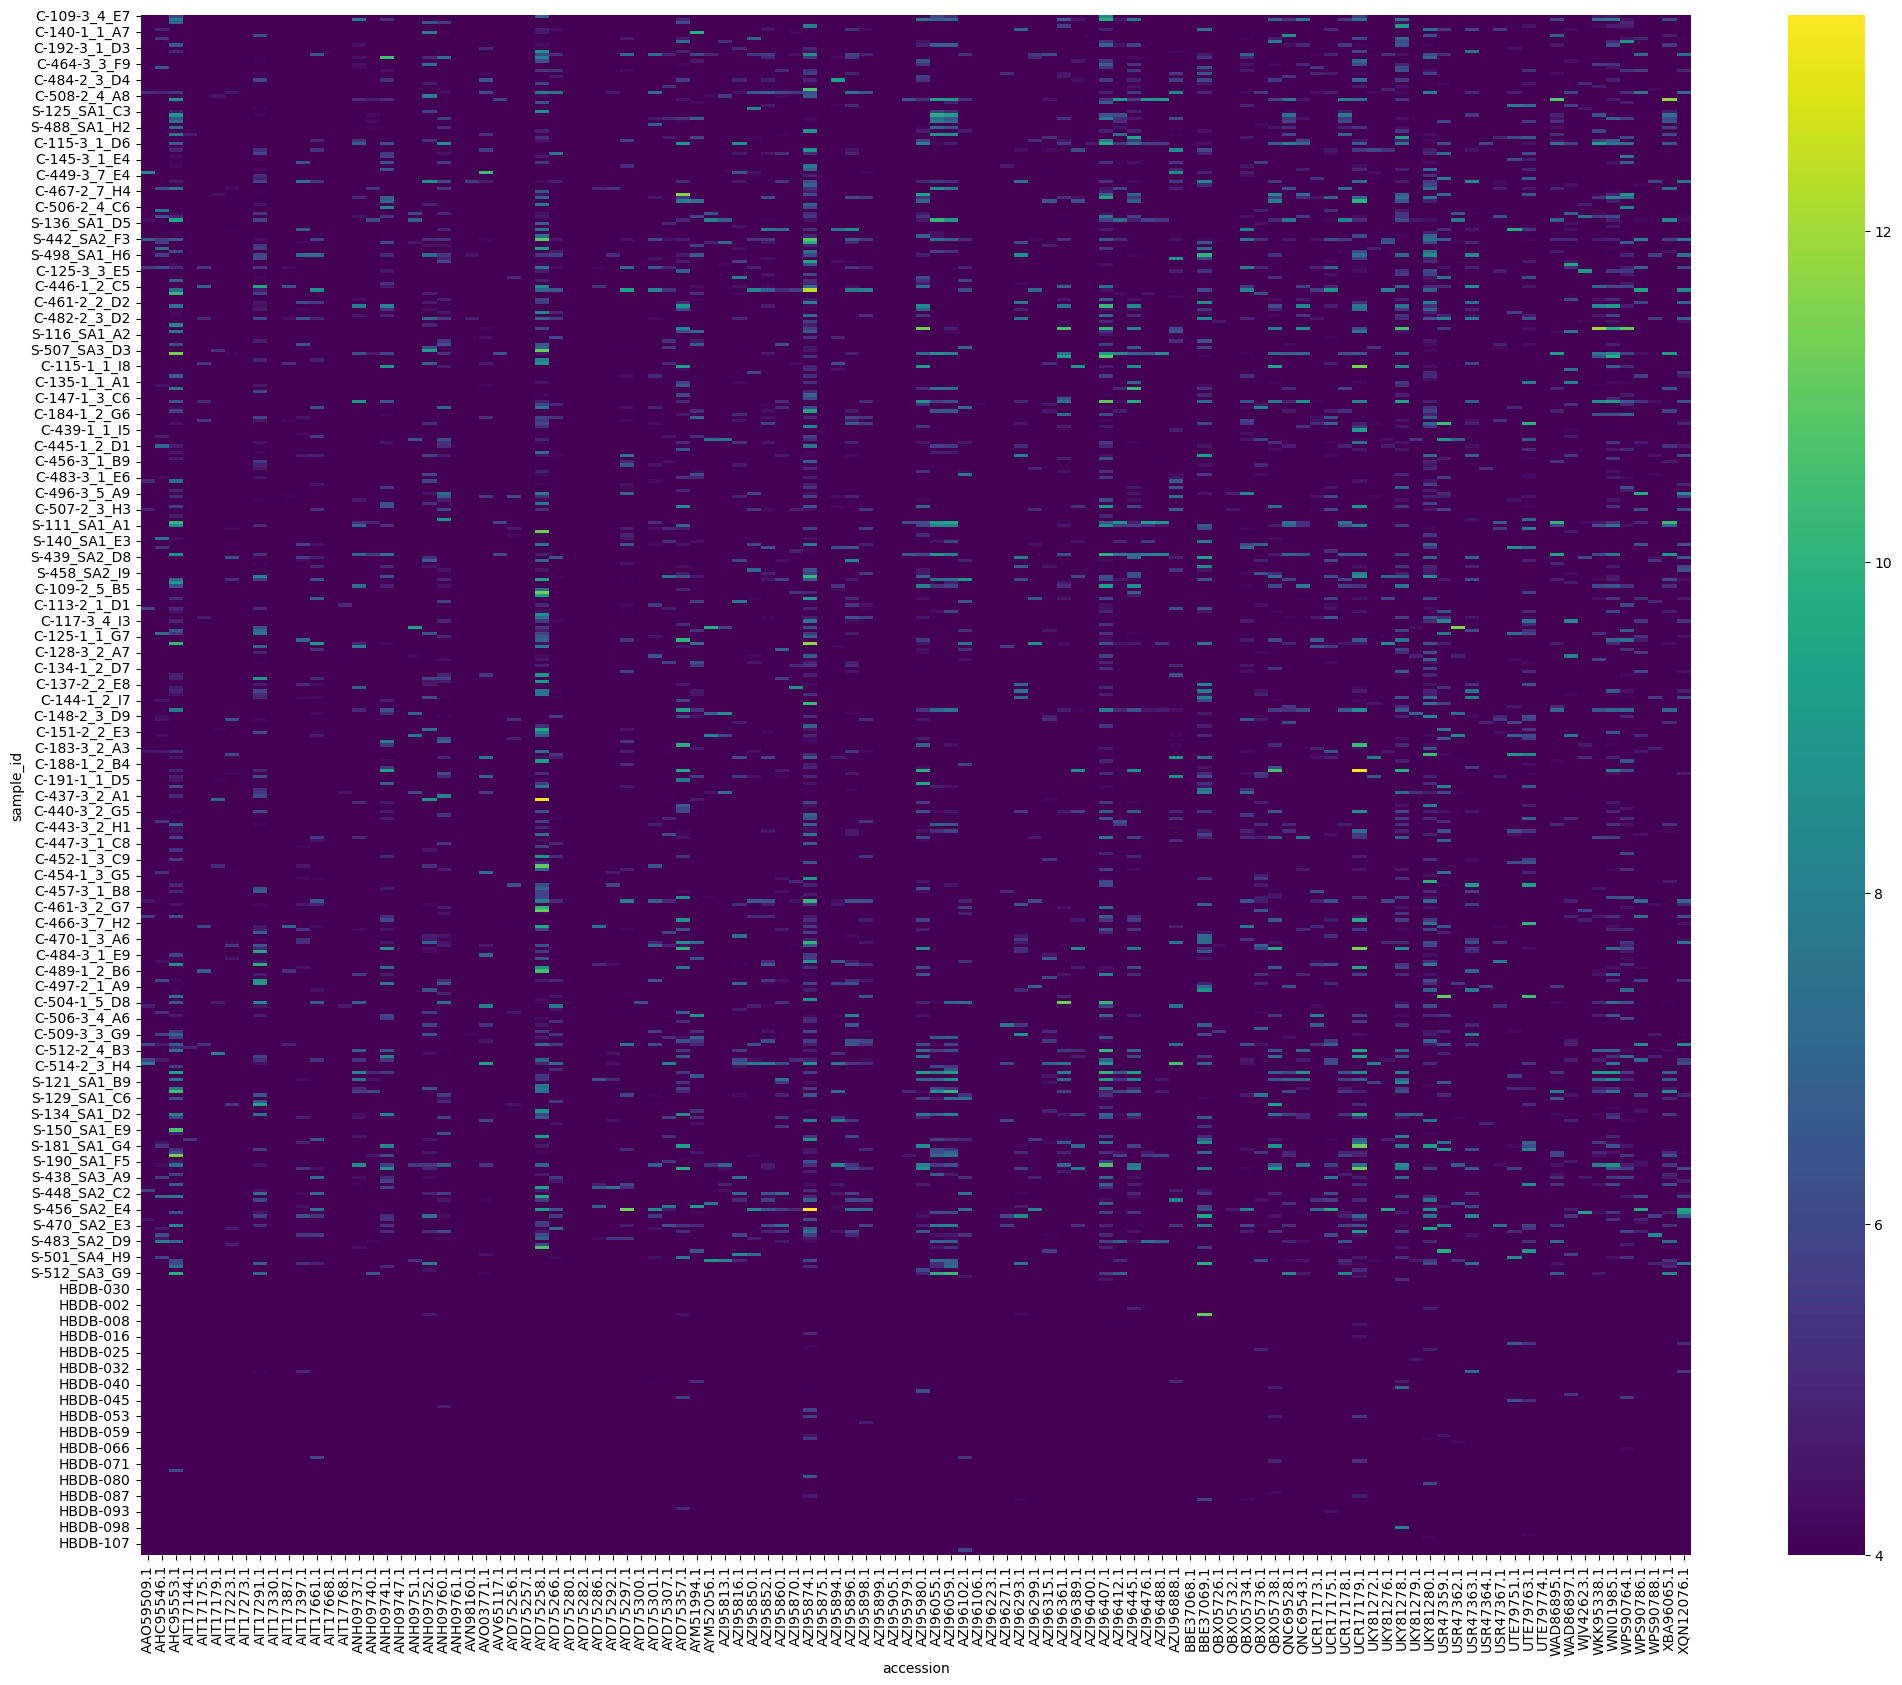

In [ ]:
import seaborn as sns

row_order = list(df_SL.columns) + list(df_hbdb.columns) #order has to be a list

pivot_df = pivot_df_raw.loc[row_order]

plt.figure(figsize=(25, 20))

ax = sns.heatmap(np.log2(pivot_df), cmap='viridis', vmin=4)

ax.tick_params(axis='y', labelleft=True)


plt.show()


### maybe try on a z score level

In [ ]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

